###**Alishba Bacha**

###**2022088 - AI**

###**AI-351 Lab 10 Tasks**

#####**TASK1**

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


####preprocessing

In [4]:
print(data.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [6]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:, :-1])

####Implementation of K-Means


In [8]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(data_scaled)
data['cluster'] = kmeans.labels_

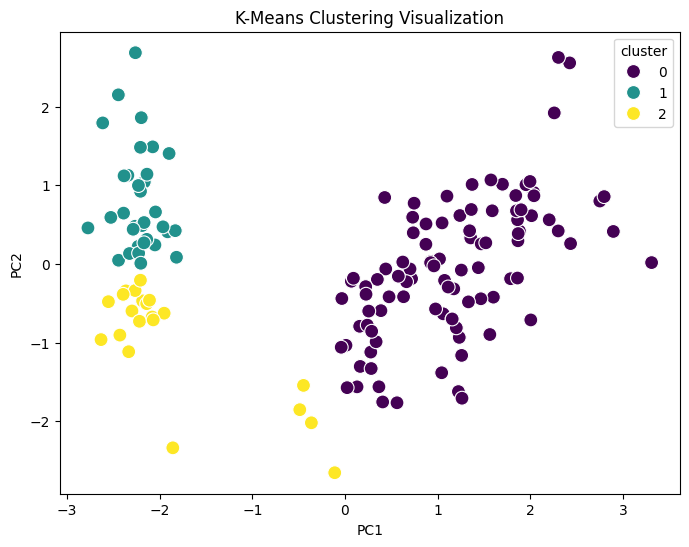

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
data_pca_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
data_pca_df['cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=data_pca_df, palette='viridis', s=100)
plt.title("K-Means Clustering Visualization")
plt.show()

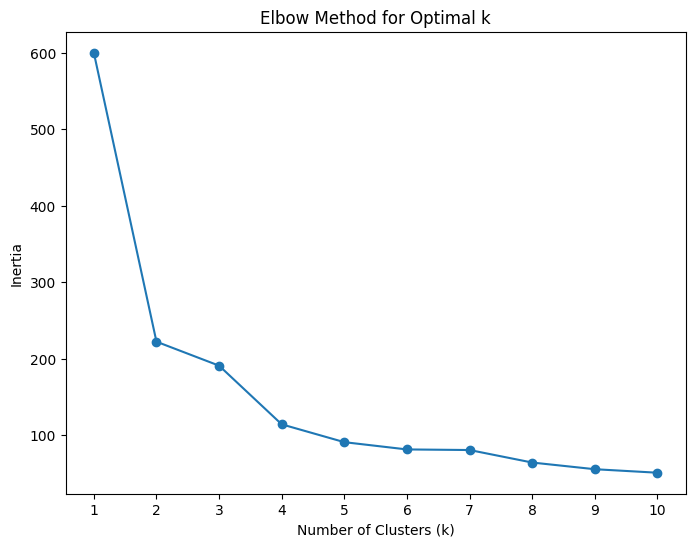

In [10]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, '-o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.show()

####**Task2**

In [11]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [13]:
print("Missing values:", df.isnull().sum())

Missing values: sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [15]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

In [16]:
k = 3
kmeans_random = KMeans(n_clusters=k, init='random', random_state=42, max_iter=300)
kmeans_plus = KMeans(n_clusters=k, init='k-means++', random_state=42, max_iter=300)

In [20]:
kmeans_random.fit(data_scaled)
kmeans_plus.fit(data_scaled)
labels_random = kmeans_random.labels_
labels_plus = kmeans_plus.labels_
inertia_random = kmeans_random.inertia_
inertia_plus = kmeans_plus.inertia_
silhouette_random = silhouette_score(data_scaled, labels_random)
silhouette_plus = silhouette_score(data_scaled, labels_plus)
iterations_random = kmeans_random.n_iter_
iterations_plus = kmeans_plus.n_iter_
print("Random Initialization : \nInertia:", inertia_random, "\nSilhouette Score:", silhouette_random, "\nIterations:", iterations_random)
print("\nK-Means++ Initialization : \nInertia:", inertia_plus, "\nSilhouette Score:", silhouette_plus, "\nIterations:", iterations_plus)

Random Initialization : 
Inertia: 139.825434661742 
Silhouette Score: 0.45937792074496625 
Iterations: 5

K-Means++ Initialization : 
Inertia: 191.02473685317958 
Silhouette Score: 0.4798814508199817 
Iterations: 4


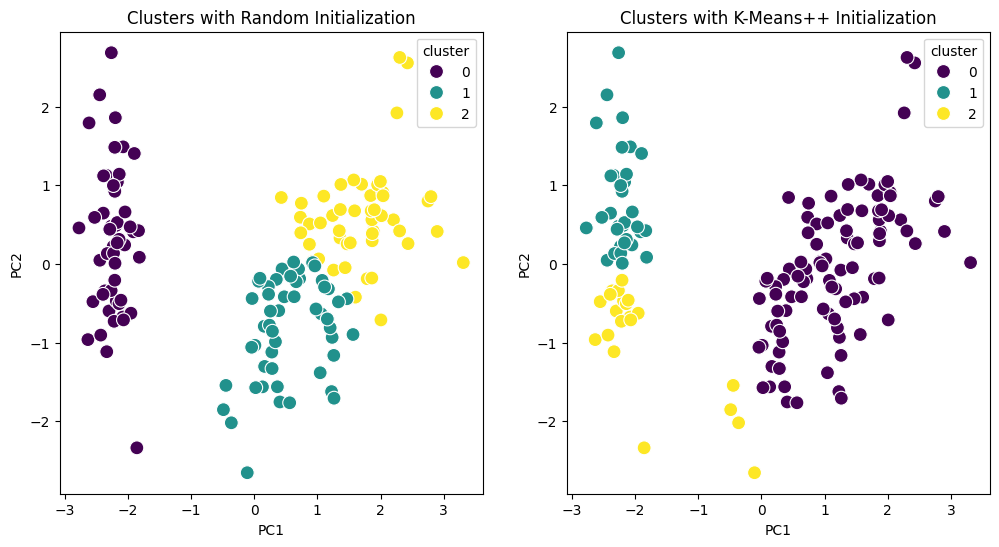

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
df_random = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
df_random['cluster'] = labels_random

df_plus = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
df_plus['cluster'] = labels_plus
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_random, palette='viridis', s=100)
plt.title("Clusters with Random Initialization")

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_plus, palette='viridis', s=100)
plt.title("Clusters with K-Means++ Initialization")
plt.show()
